# Câu 3: Wine Clustering

# 1. DATA UNDERSTANDING & EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
# 1. Load raw dataset

df = pd.read_csv('wine-clustering.csv')

In [4]:
# 2. Data Quality Check

print("--- DATA QUALITY CHECK ---")
print(f"Kích thước dữ liệu: {df.shape}")
print(f"Số lượng bản ghi trùng lặp: {df.duplicated().sum()}")
print("Số lượng missing values ở mỗi cột:")
print(df.isnull().sum())

--- DATA QUALITY CHECK ---
Kích thước dữ liệu: (178, 13)
Số lượng bản ghi trùng lặp: 0
Số lượng missing values ở mỗi cột:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


In [5]:
# 3.EDA - Thống kê mô tả

print("\n--- THỐNG KÊ MÔ TẢ ---")
print(df.describe().T)


--- THỐNG KÊ MÔ TẢ ---
                      count        mean         std     min       25%  \
Alcohol               178.0   13.000618    0.811827   11.03   12.3625   
Malic_Acid            178.0    2.336348    1.117146    0.74    1.6025   
Ash                   178.0    2.366517    0.274344    1.36    2.2100   
Ash_Alcanity          178.0   19.494944    3.339564   10.60   17.2000   
Magnesium             178.0   99.741573   14.282484   70.00   88.0000   
Total_Phenols         178.0    2.295112    0.625851    0.98    1.7425   
Flavanoids            178.0    2.029270    0.998859    0.34    1.2050   
Nonflavanoid_Phenols  178.0    0.361854    0.124453    0.13    0.2700   
Proanthocyanins       178.0    1.590899    0.572359    0.41    1.2500   
Color_Intensity       178.0    5.058090    2.318286    1.28    3.2200   
Hue                   178.0    0.957449    0.228572    0.48    0.7825   
OD280                 178.0    2.611685    0.709990    1.27    1.9375   
Proline               178.0

In [6]:
# 4. Boxplot & Correlation Heatmap

Text(0.5, 1.0, 'Distribution of Wine Features')

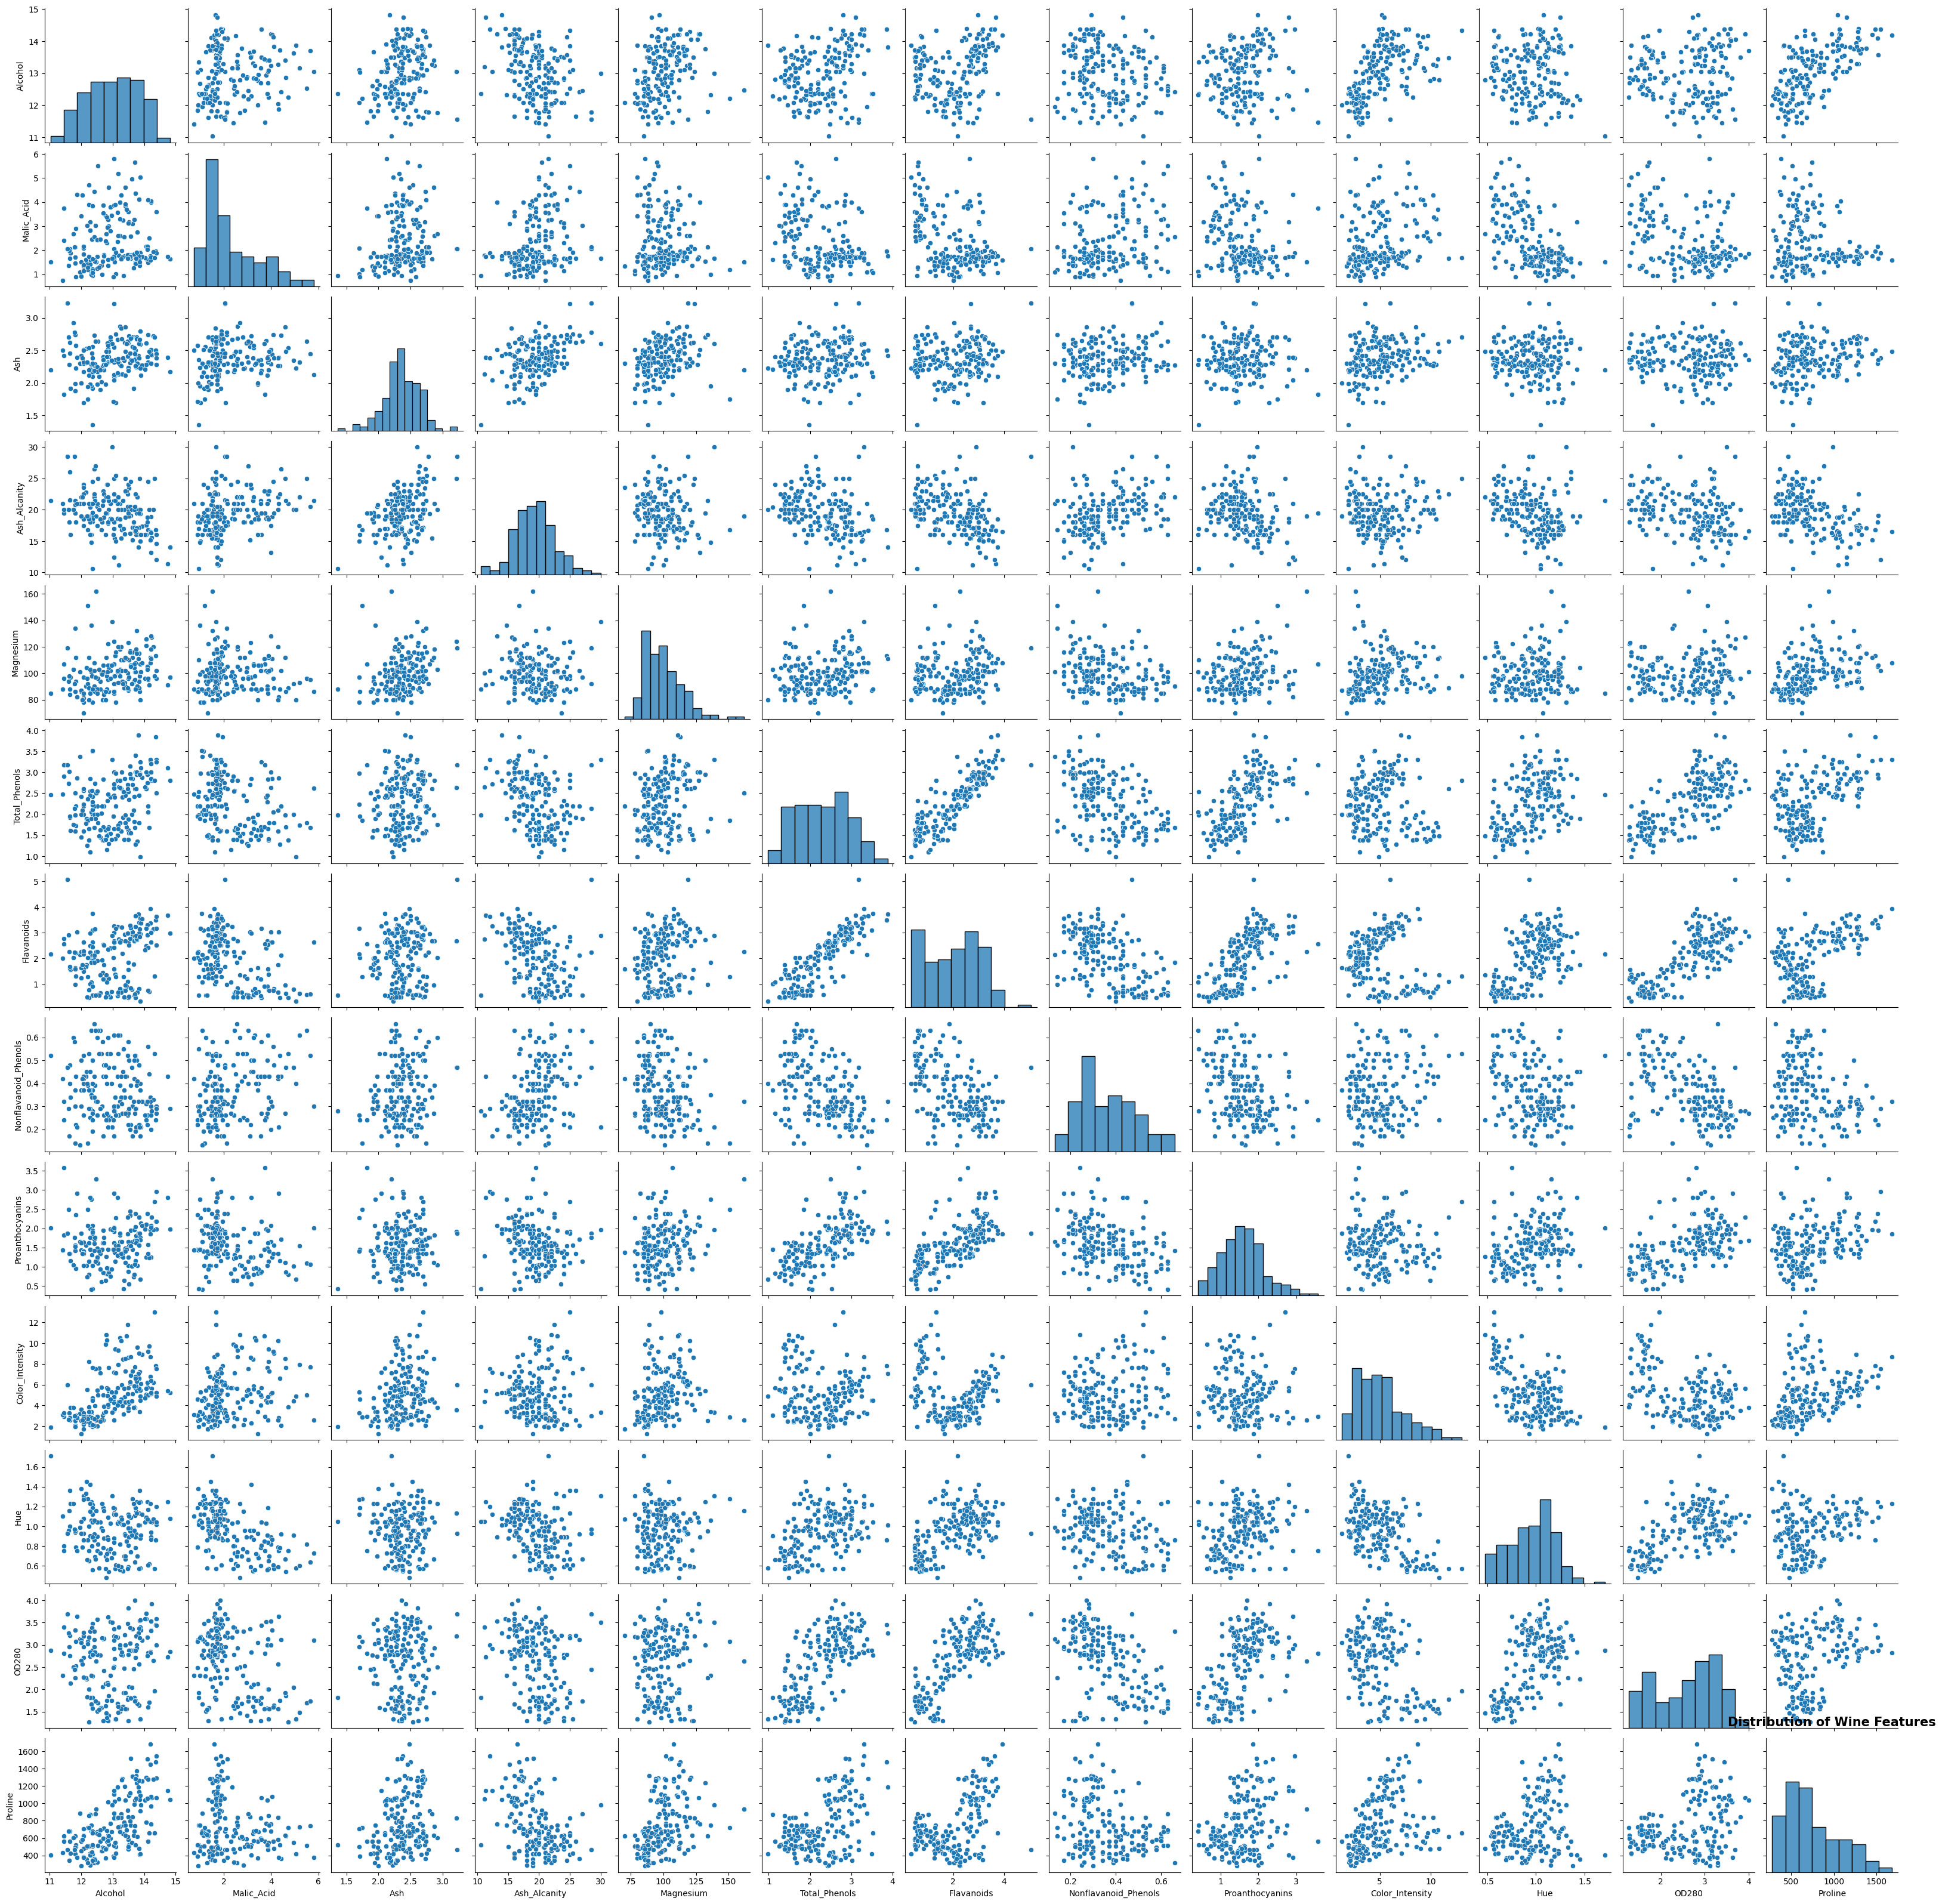

In [7]:
# Pairplot

sns.pairplot(df)
plt.title('Distribution of Wine Features', fontsize=15, fontweight='bold', pad=15)

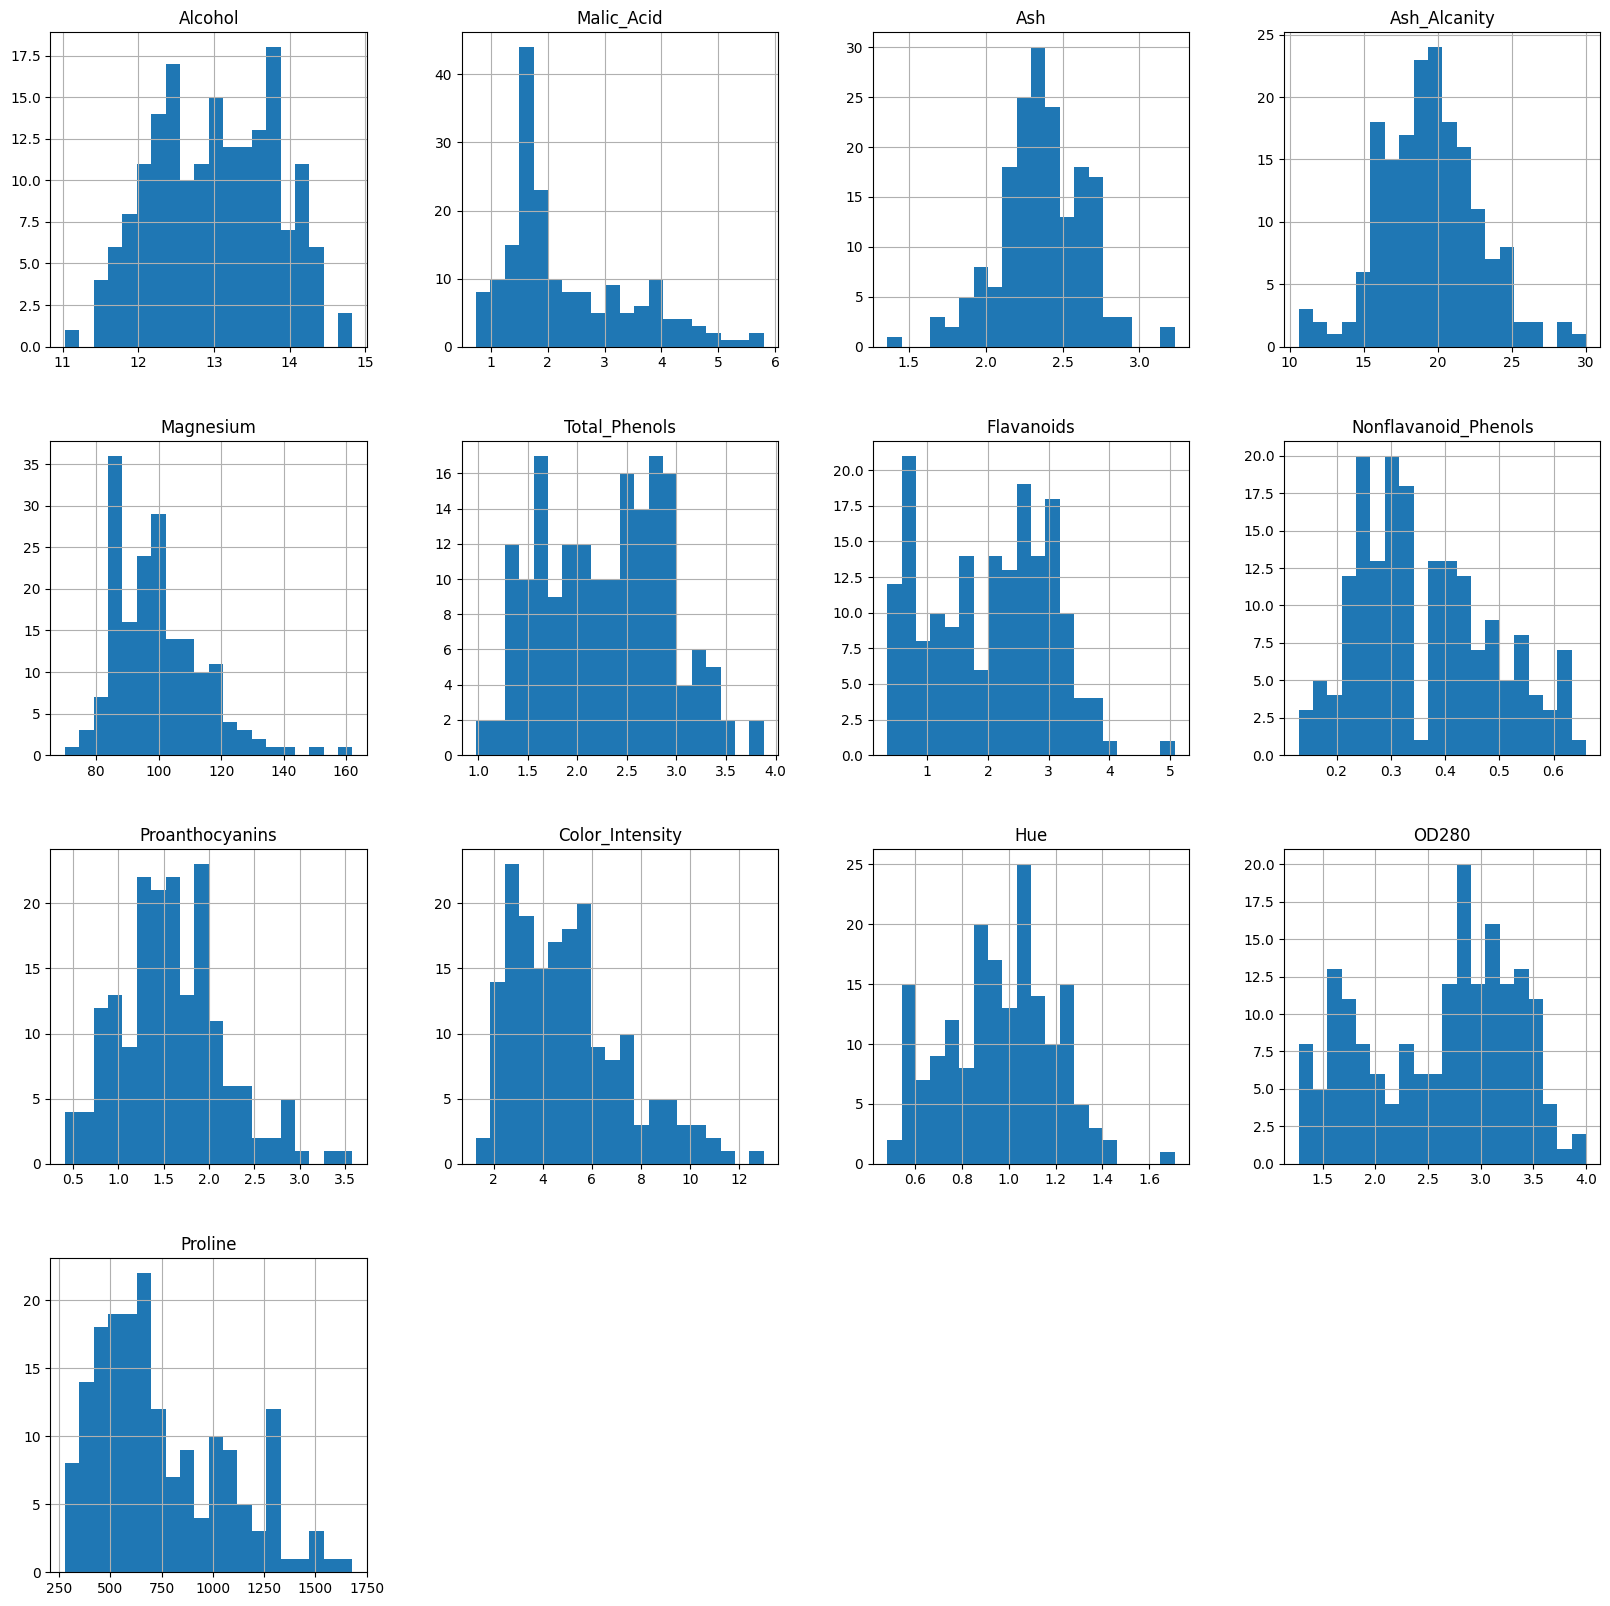

In [8]:
# Histogram

plt.rcParams["figure.figsize"] = (20, 20)
df.hist(bins=20)
plt.show()

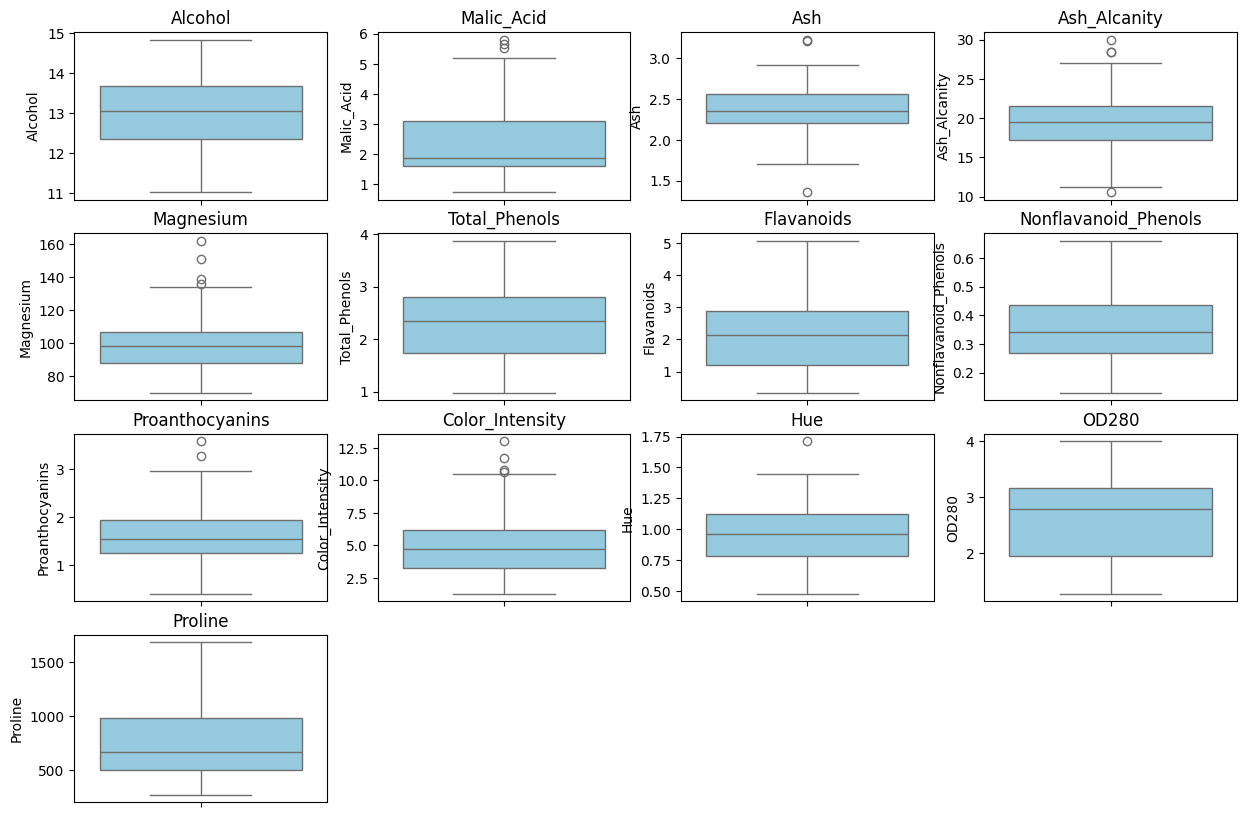

In [9]:
# Trực quan hóa Phân phối & Outliers

plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.show()

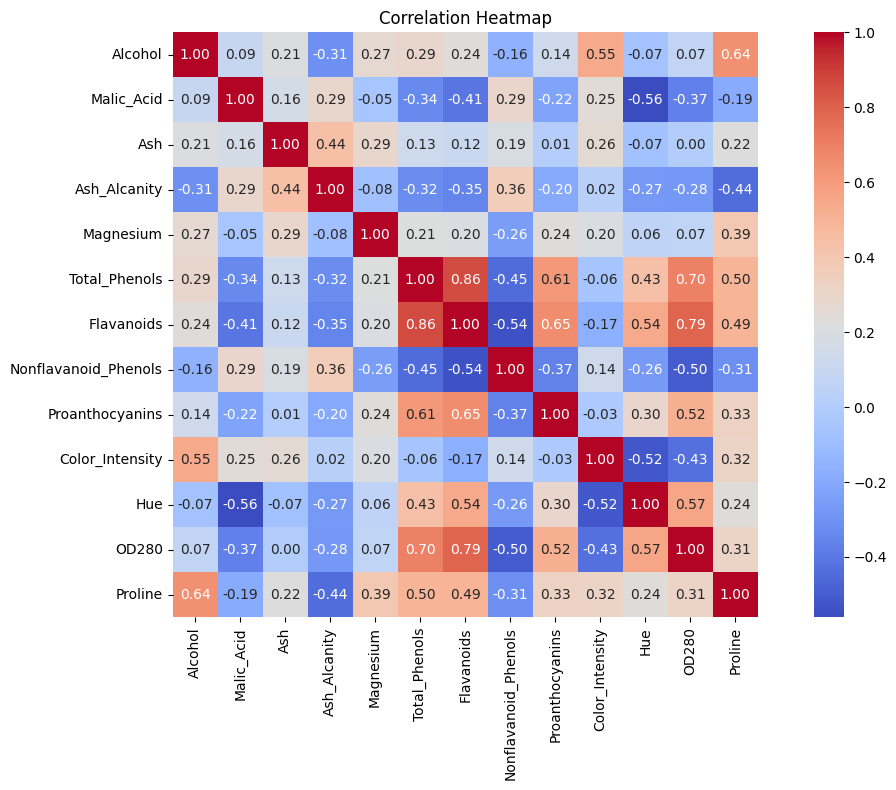

In [10]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

***** REMARK *****

- Bộ dữ liệu wine gồm các biến hóa học có thang đo khá khác nhau, một số biến như Proline, Alcohol, Color Intensity có độ phân tán lớn hơn các biến còn lại

- Qua histogram, boxplot và correlation heatmap, có thể thấy dữ liệu có sự khác biệt rõ giữa các mẫu rượu và tồn tại một số biến có tương quan với nhau

- Điều này cho thấy dữ liệu có tiềm năng để phân cụm, nhưng cần chuẩn hóa trước khi áp dụng K-Means để tránh biến có giá trị lớn chi phối khoảng cách

- Các giá trị ngoại lệ (outliers) trên các biến này được quyết định giữ lại hoàn toàn vì chúng có thể phản ánh đặc tính tự nhiên của các dòng rượu đặc thù (như vang thượng hạng, đậm vị)

# 2. DATA PREPROCESSING & PCA (Tiền xử lý & Giảm chiều dữ liệu)

In [11]:
# 1. Feature scaling with StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

In [12]:
# 2. Save scaled dataset for BigQuery ML

df_scaled.to_csv('wine_scaled.csv', index=False)
print("\n[SUCCESS] Đã xuất file wine_scaled.csv chuẩn bị cho BigQuery ML.")


[SUCCESS] Đã xuất file wine_scaled.csv chuẩn bị cho BigQuery ML.


In [13]:
# 3. CPA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nTỷ lệ phương sai giải thích (Explained Variance Ratio) của 2 PC đầu: {pca.explained_variance_ratio_}")
print(f"Tổng phương sai giải thích bởi PC1 và PC2: {sum(pca.explained_variance_ratio_)*100:.2f}%")


Tỷ lệ phương sai giải thích (Explained Variance Ratio) của 2 PC đầu: [0.36198848 0.1920749 ]
Tổng phương sai giải thích bởi PC1 và PC2: 55.41%


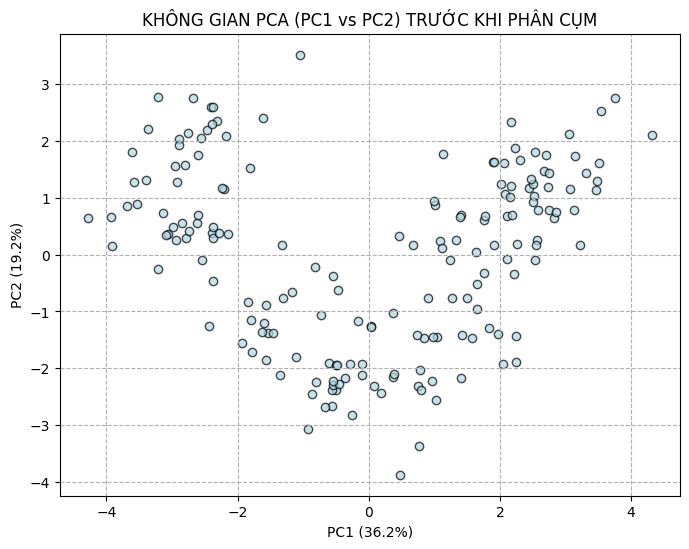

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='lightblue', alpha=0.7, edgecolors='k')
plt.title('KHÔNG GIAN PCA (PC1 vs PC2) TRƯỚC KHI PHÂN CỤM')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--')
plt.show()

In [15]:
# 4. Save PCA-transformed dataset

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca.to_csv('wine_pca.csv', index=False)
print("[SUCCESS] Đã lưu file wine_pca.csv thành công")

[SUCCESS] Đã lưu file wine_pca.csv thành công


# 3. MODELING & EVALUATION 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
import matplotlib.cm as cm

In [17]:
# 1. Load clustering outputs from BigQuery 

df_original = pd.read_csv('wine-clustering.csv')
df_scaled = pd.read_csv('wine_scaled.csv')
df_pca = pd.read_csv('wine_pca.csv')

res_k3 = pd.read_csv('wine_predictions_k3.csv')
res_k4 = pd.read_csv('wine_predictions_k4.csv')

# Tự động nhận diện cột chứa Cluster ID để tránh lỗi KeyError
actual_col_name_k3 = [col for col in res_k3.columns if 'centroid' in col.lower()][0]
actual_col_name_k4 = [col for col in res_k4.columns if 'centroid' in col.lower()][0]

df_original['Cluster'] = res_k3[actual_col_name_k3]
df_pca['cluster_k3'] = res_k3[actual_col_name_k3]
df_pca['cluster_k4'] = res_k4[actual_col_name_k4]

X_scaled = df_scaled.values 
cluster_labels = df_original['Cluster'].values

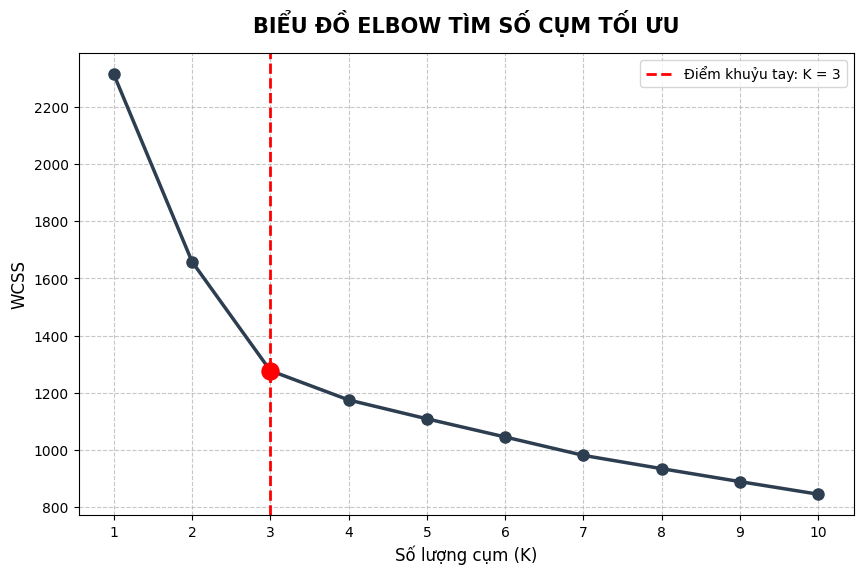

In [18]:
# 2. Elbow method

wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='#2c3e50', linewidth=2.5, markersize=8)
plt.title('BIỂU ĐỒ ELBOW TÌM SỐ CỤM TỐI ƯU', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Số lượng cụm (K)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=3, color='red', linestyle='--', linewidth=2, label='Điểm khuỷu tay: K = 3')
plt.scatter([3], [wcss[2]], color='red', s=150, zorder=5) 
plt.legend()
plt.show()

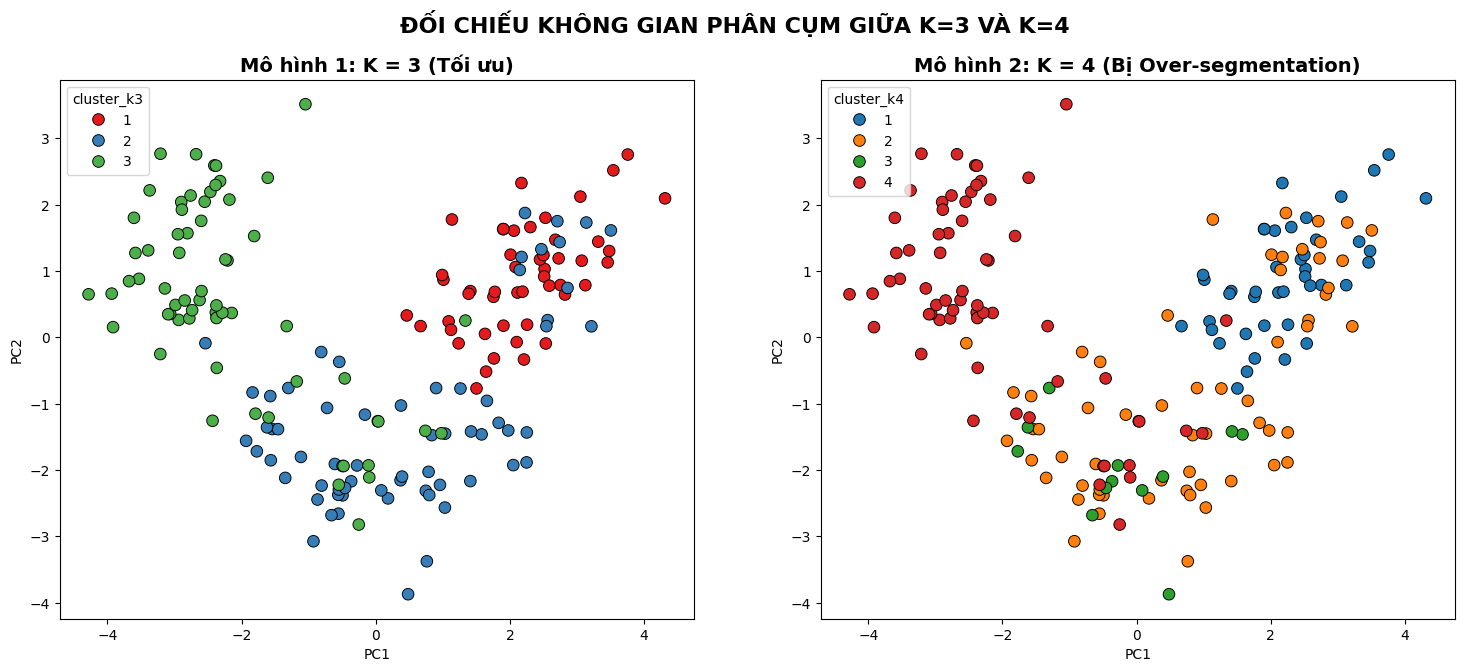

In [19]:
# 3. PCA scatter comparison (K=3 vs K=4) (PCA 2D)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(ax=axes[0], x='PC1', y='PC2', hue='cluster_k3', data=df_pca, palette='Set1', s=70, edgecolor='k')
axes[0].set_title('Mô hình 1: K = 3 (Tối ưu)', fontsize=14, fontweight='bold')

sns.scatterplot(ax=axes[1], x='PC1', y='PC2', hue='cluster_k4', data=df_pca, palette='tab10', s=70, edgecolor='k')
axes[1].set_title('Mô hình 2: K = 4 (Bị Over-segmentation)', fontsize=14, fontweight='bold')

plt.suptitle('ĐỐI CHIẾU KHÔNG GIAN PHÂN CỤM GIỮA K=3 VÀ K=4', fontsize=16, fontweight='bold')
plt.show()

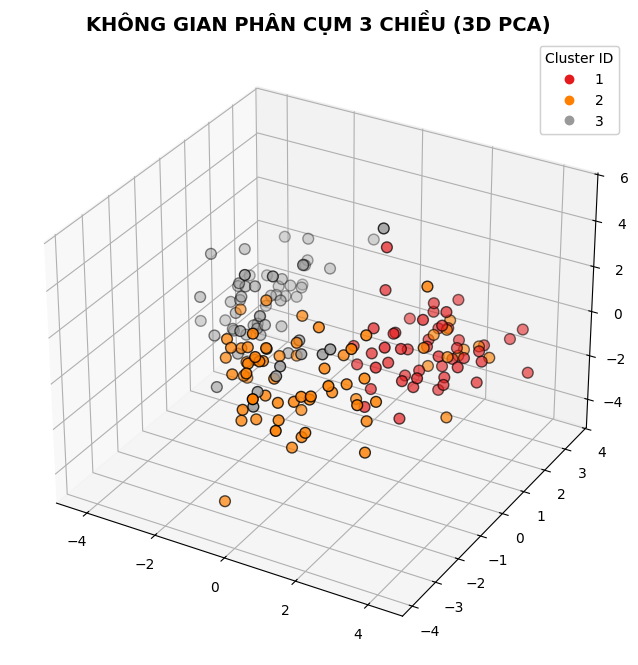

In [20]:
# 4. 3D PCA visualization

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=cluster_labels, cmap='Set1', s=60, edgecolor='k')
ax.set_title('KHÔNG GIAN PHÂN CỤM 3 CHIỀU (3D PCA)', fontsize=14, fontweight='bold')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster ID")
ax.add_artist(legend1)
plt.show()


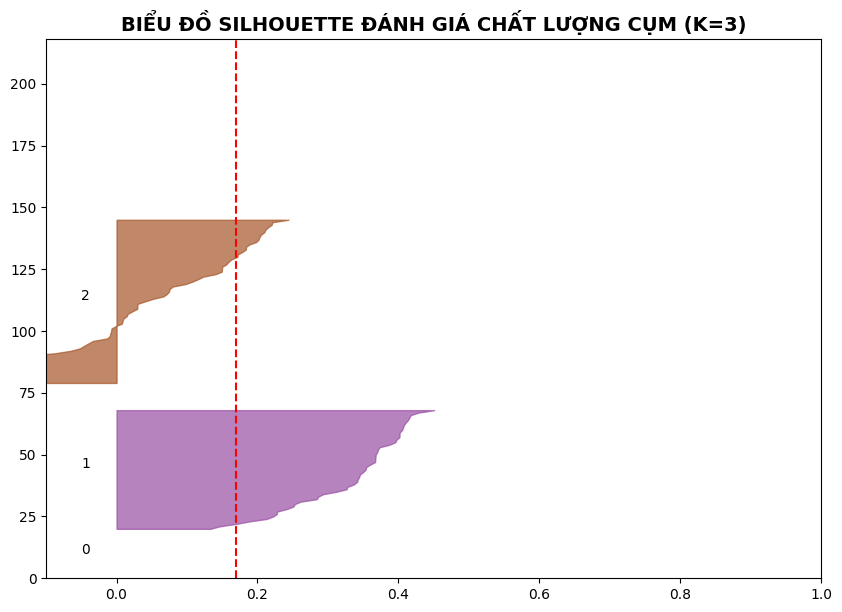

In [21]:
# 5. Silhouette plot + silhouette score

fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X_scaled) + (3 + 1) * 10])

silhouette_avg = silhouette_score(X_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

y_lower = 10
for i in range(3):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.Set1(float(i) / 3)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_title("BIỂU ĐỒ SILHOUETTE ĐÁNH GIÁ CHẤT LƯỢNG CỤM (K=3)", fontsize=14, fontweight='bold')
plt.show()

***** REMARK *****

- Kết quả từ Elbow Method, PCA scatter plot và Silhouette Analysis cho thấy K = 3 là lựa chọn hợp lý hơn so với K = 4 (K=4 đã gây ra hiện tượng Over-segmentation (chia cắt dư thừa), làm các dải sản phẩm bị đè lấn lộn xộn, hoàn toàn không mang lại giá trị phân loại mới cho doanh nghiệp)
  
- Với K=3, các cụm được tách biệt tương đối rõ trên không gian PCA và có mức độ chồng lấp thấp hơn
  
- Silhouette score cũng hỗ trợ rằng mô hình 3 cụm cho chất lượng phân cụm ổn định và dễ diễn giải hơn

# 4. CLUSTER INTERPRETATION

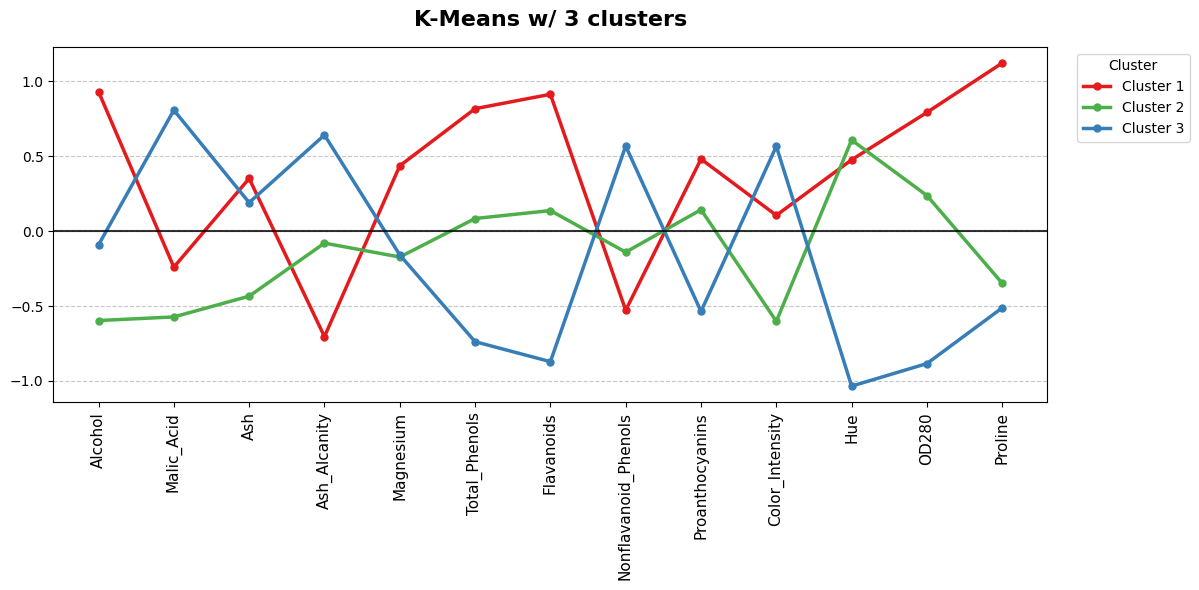

In [22]:
# 1. Cluster profile / centroid comparison

cluster_profile_scaled = df_scaled.copy()
cluster_profile_scaled['Cluster'] = df_original['Cluster']
profile_means = cluster_profile_scaled.groupby('Cluster').mean()

plt.figure(figsize=(12, 6))
colors = ['#e41a1c', '#4daf4a', '#377eb8']

for i, cluster_id in enumerate(profile_means.index):
    plt.plot(profile_means.columns, profile_means.loc[cluster_id].values, 
             marker='o', markersize=5, linewidth=2.5, label=f'Cluster {cluster_id}', color=colors[i])

plt.title('K-Means w/ 3 clusters', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=90, fontsize=11) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.axhline(0, color='black', linewidth=1.5, alpha=0.8) 
plt.legend(title='Cluster', loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()

In [23]:
df = pd.read_csv('wine-clustering.csv')
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [24]:
kmeans= KMeans(n_clusters=3,random_state=0)
kmeans.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",0
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 13)","[

In [25]:
cluster = kmeans.predict(df)
cluster
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [26]:
# 2. Profile each cluster based on key wine characteristics

df['Label']=cluster

In [27]:
df['Label']=df['Label'].map({0:'Whiskey',1:'Macallan',2:'Absolute Vodka'}).astype('object')
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Label
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,Macallan
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,Macallan
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,Macallan
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,Macallan
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,Absolute Vodka
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,Absolute Vodka
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,Absolute Vodka
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,Absolute Vodka
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,Absolute Vodka


<Axes: xlabel='Alcohol', ylabel='Count'>

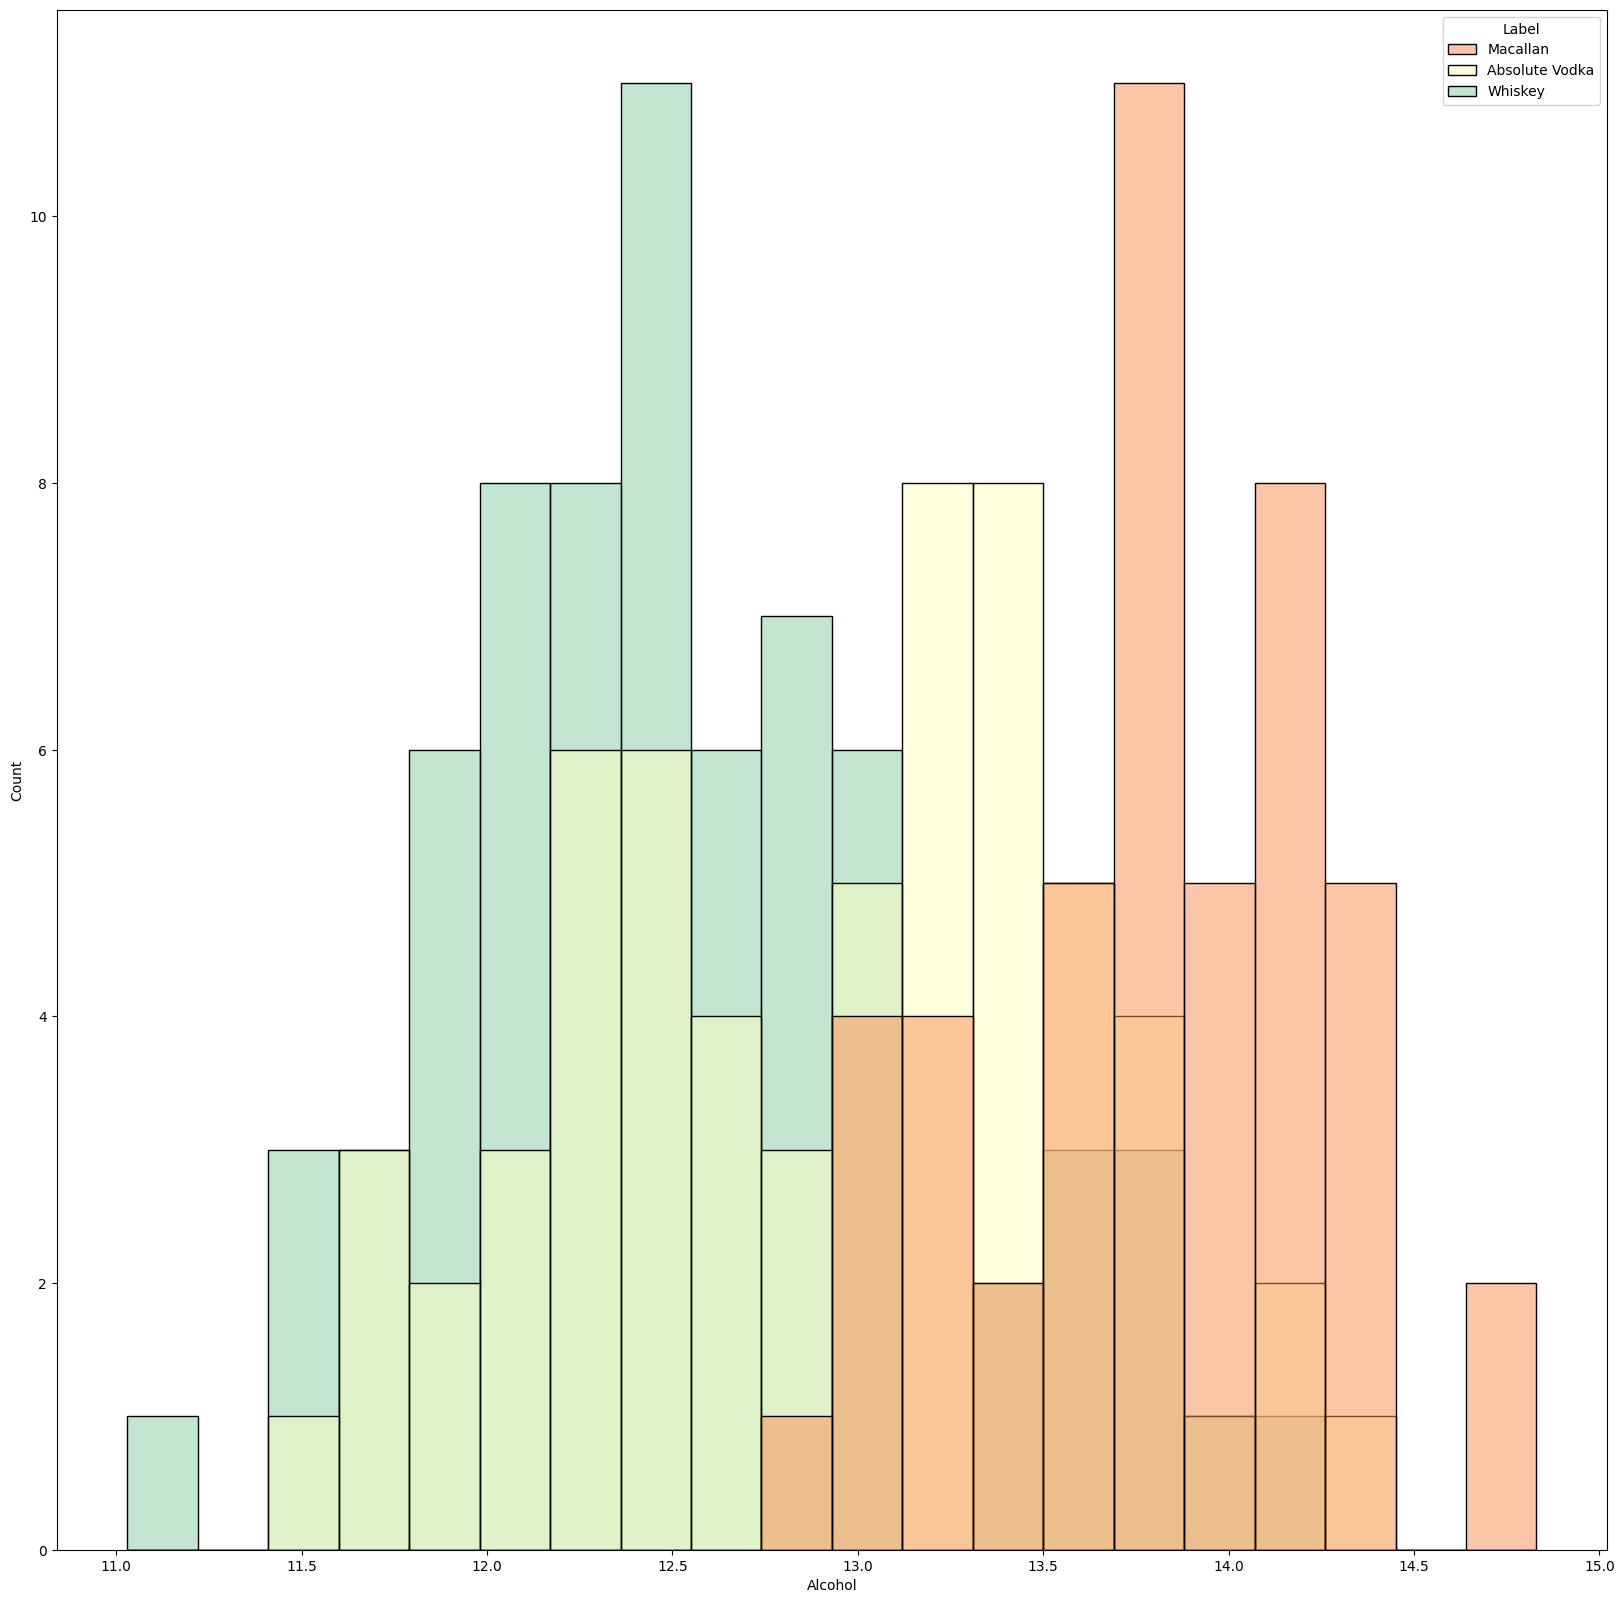

In [28]:
sns.histplot(data=df, x='Alcohol', hue='Label', palette='Spectral', bins=20)

C:\Users\KIM\AppData\Local\Temp\ipykernel_22336\1659195904.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Label'], palette='Spectral')


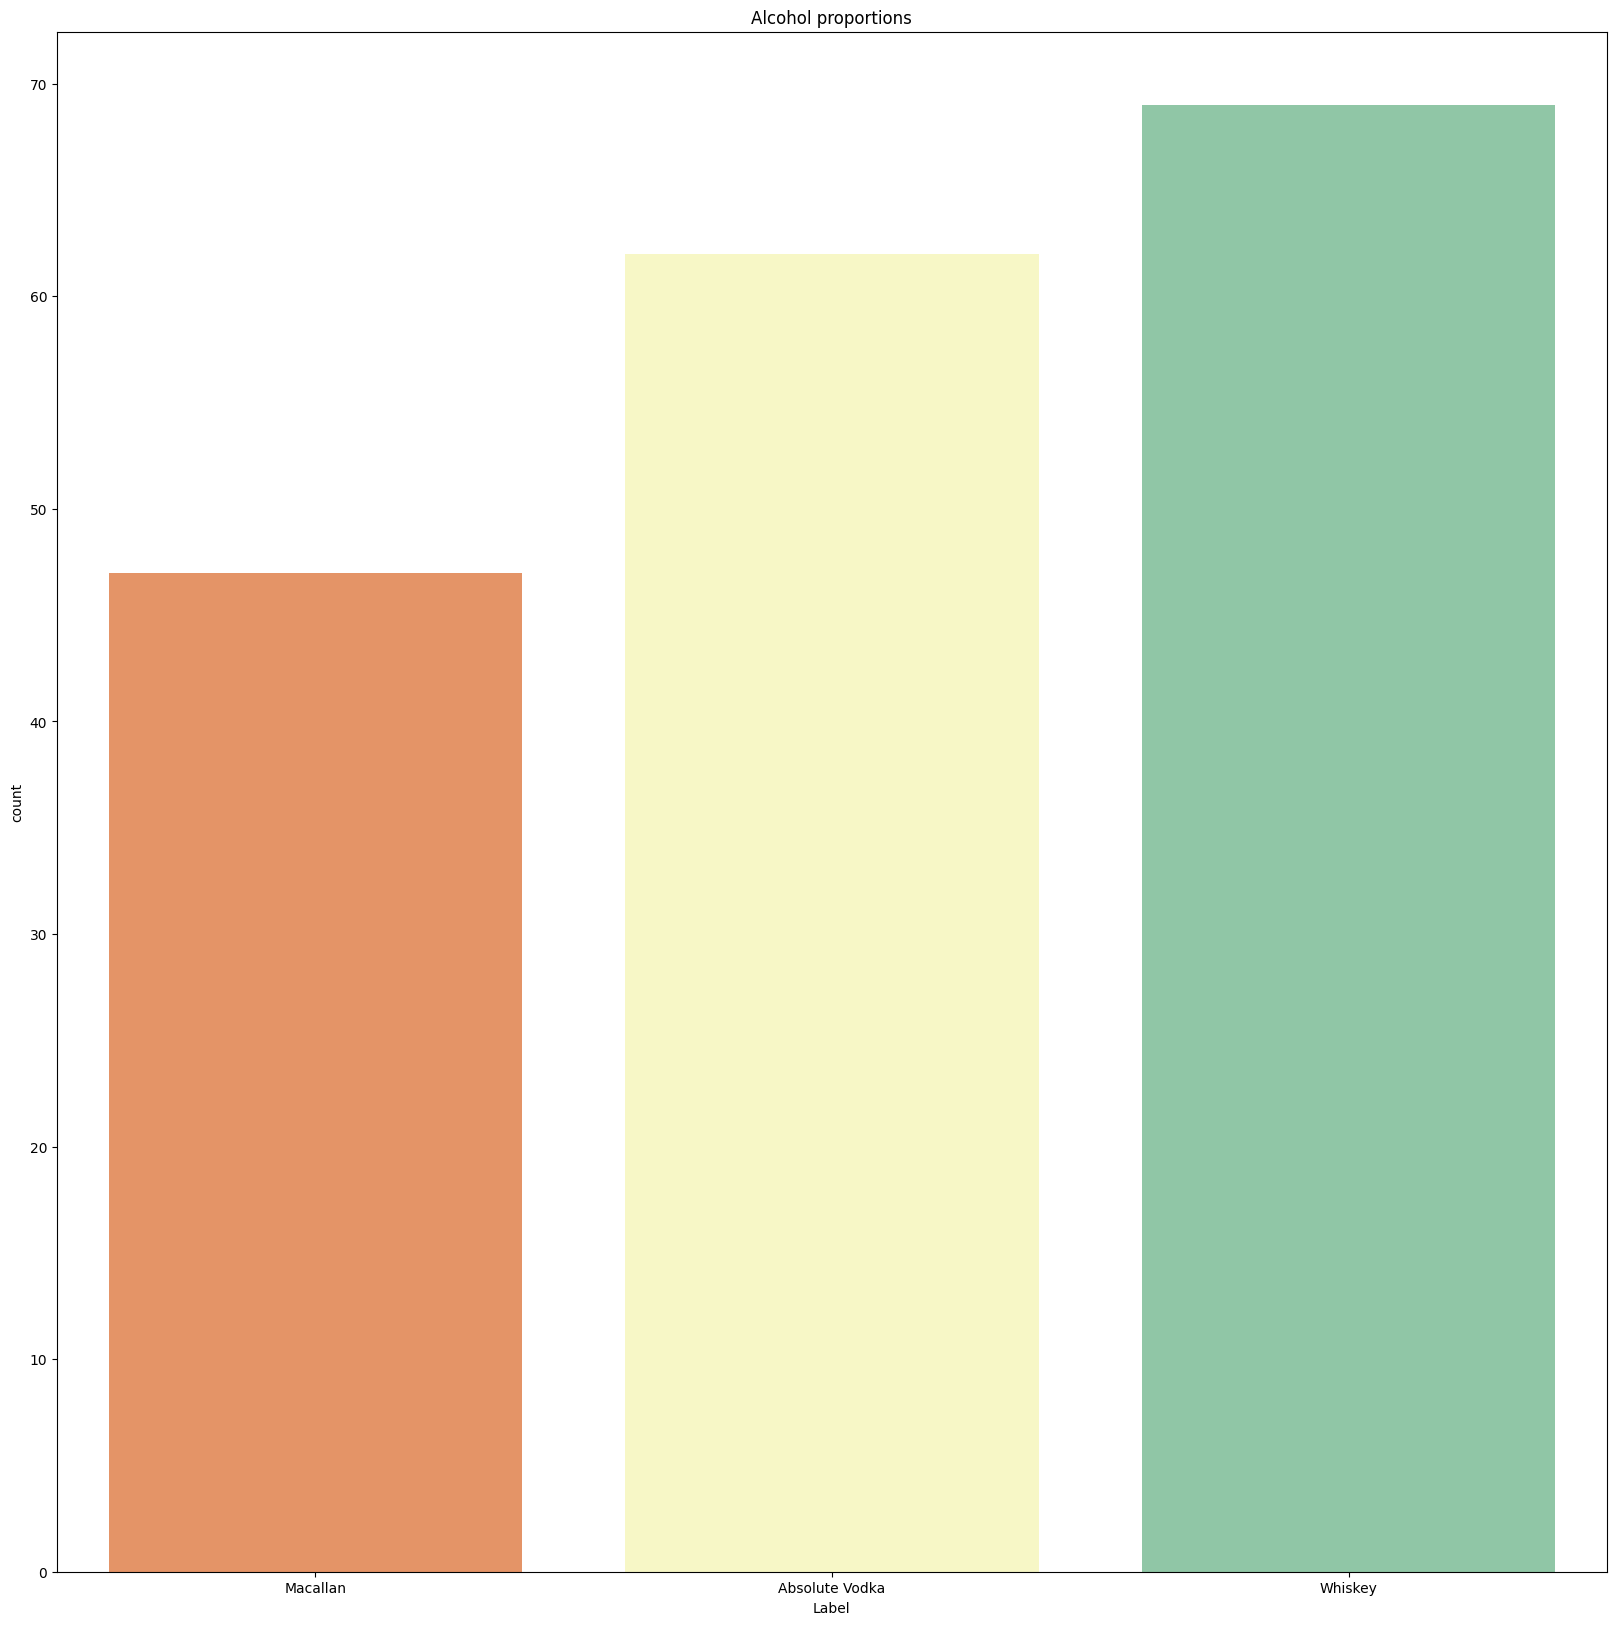

In [29]:
sns.countplot(x=df['Label'], palette='Spectral')
plt.title('Alcohol proportions')
plt.show()

<Axes: xlabel='Magnesium', ylabel='Nonflavanoid_Phenols'>

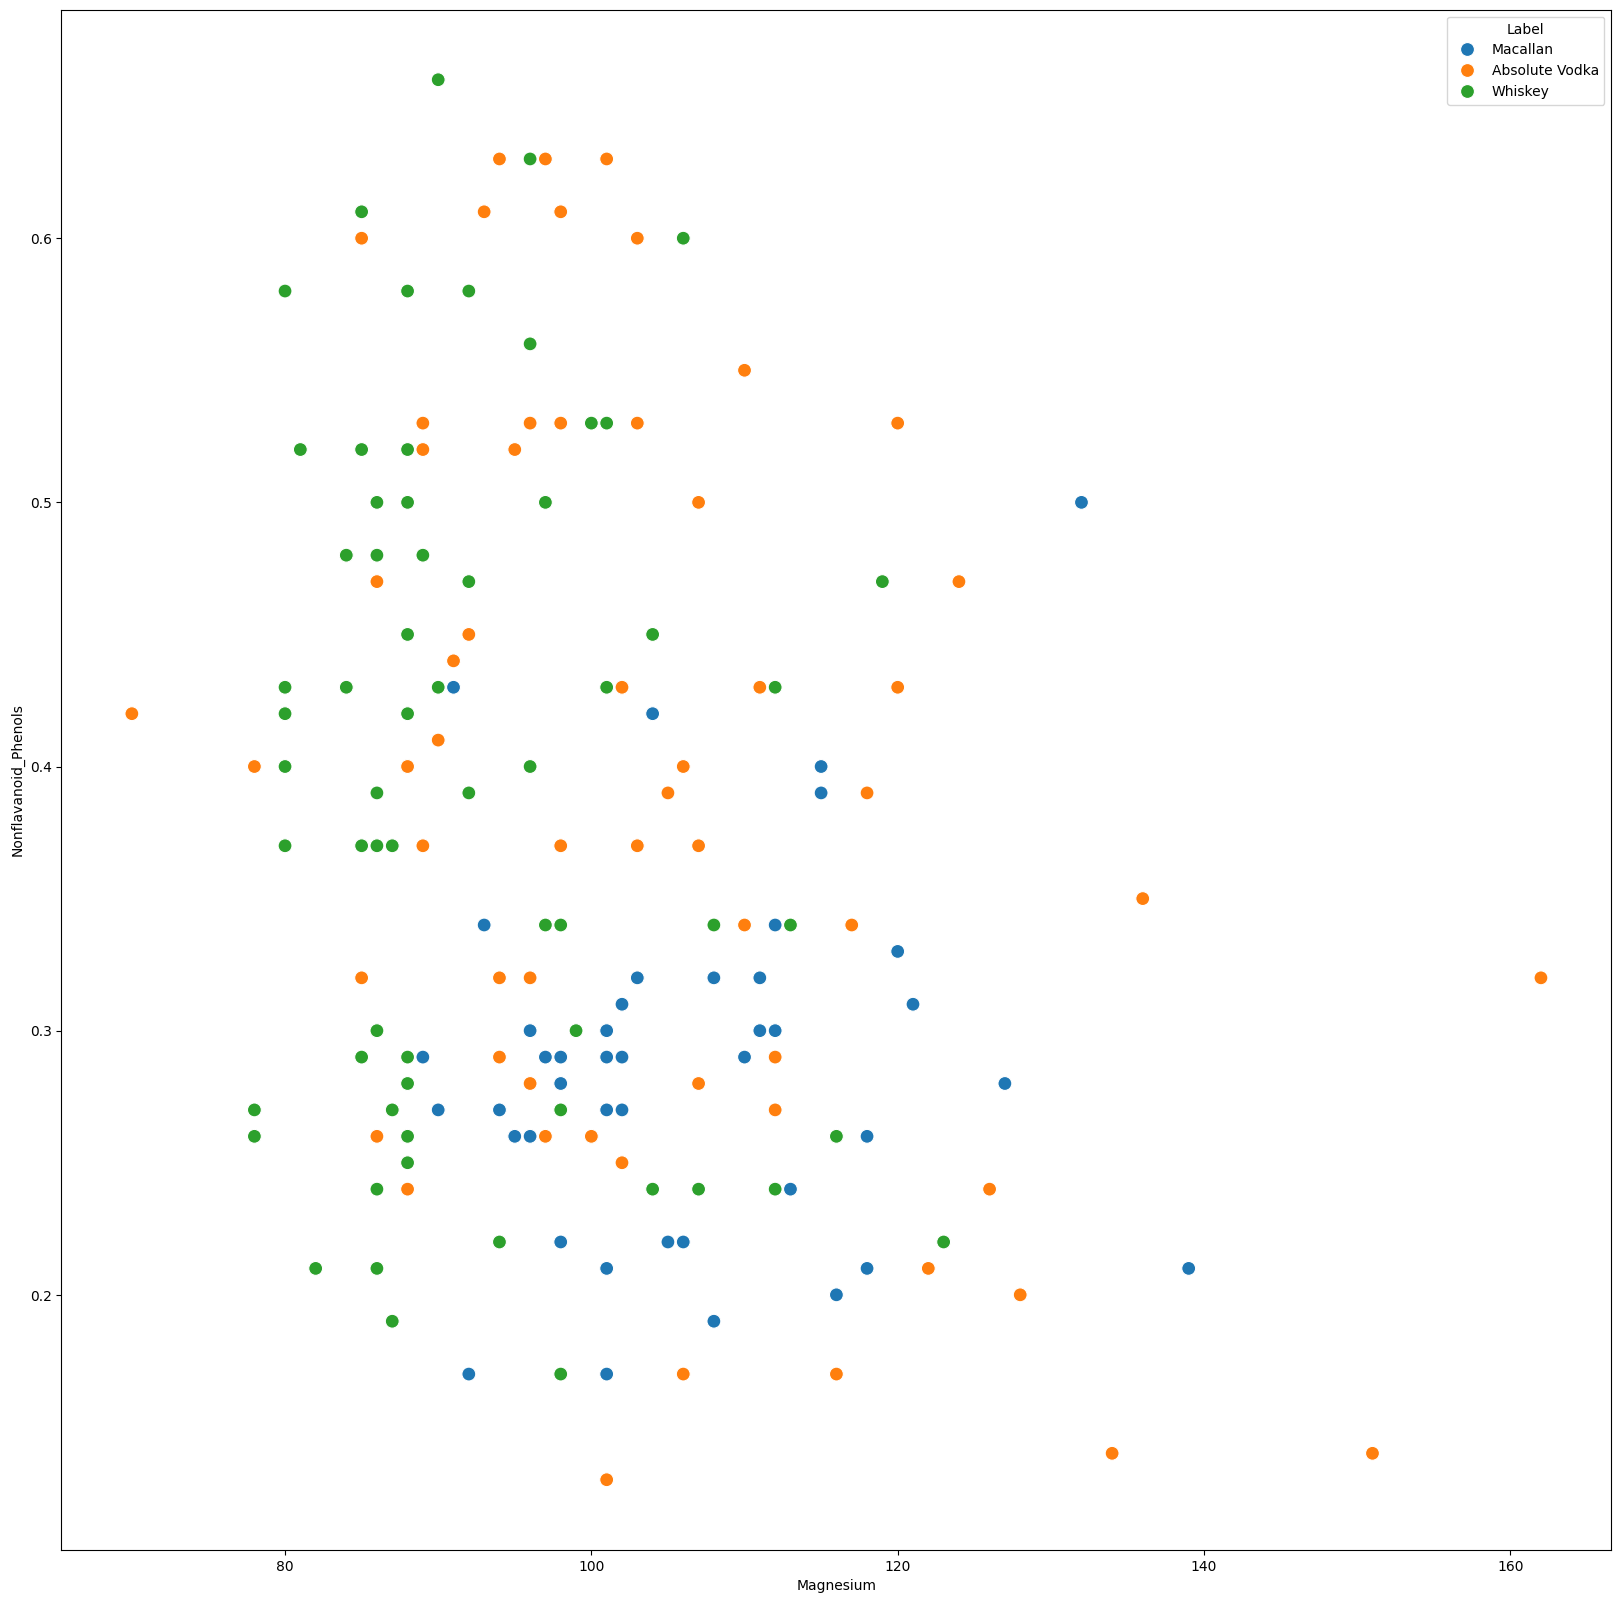

In [30]:
sns.scatterplot(data=df, x='Magnesium', y='Nonflavanoid_Phenols', hue='Label', s=100)

<Axes: xlabel='Total_Phenols', ylabel='Ash_Alcanity'>

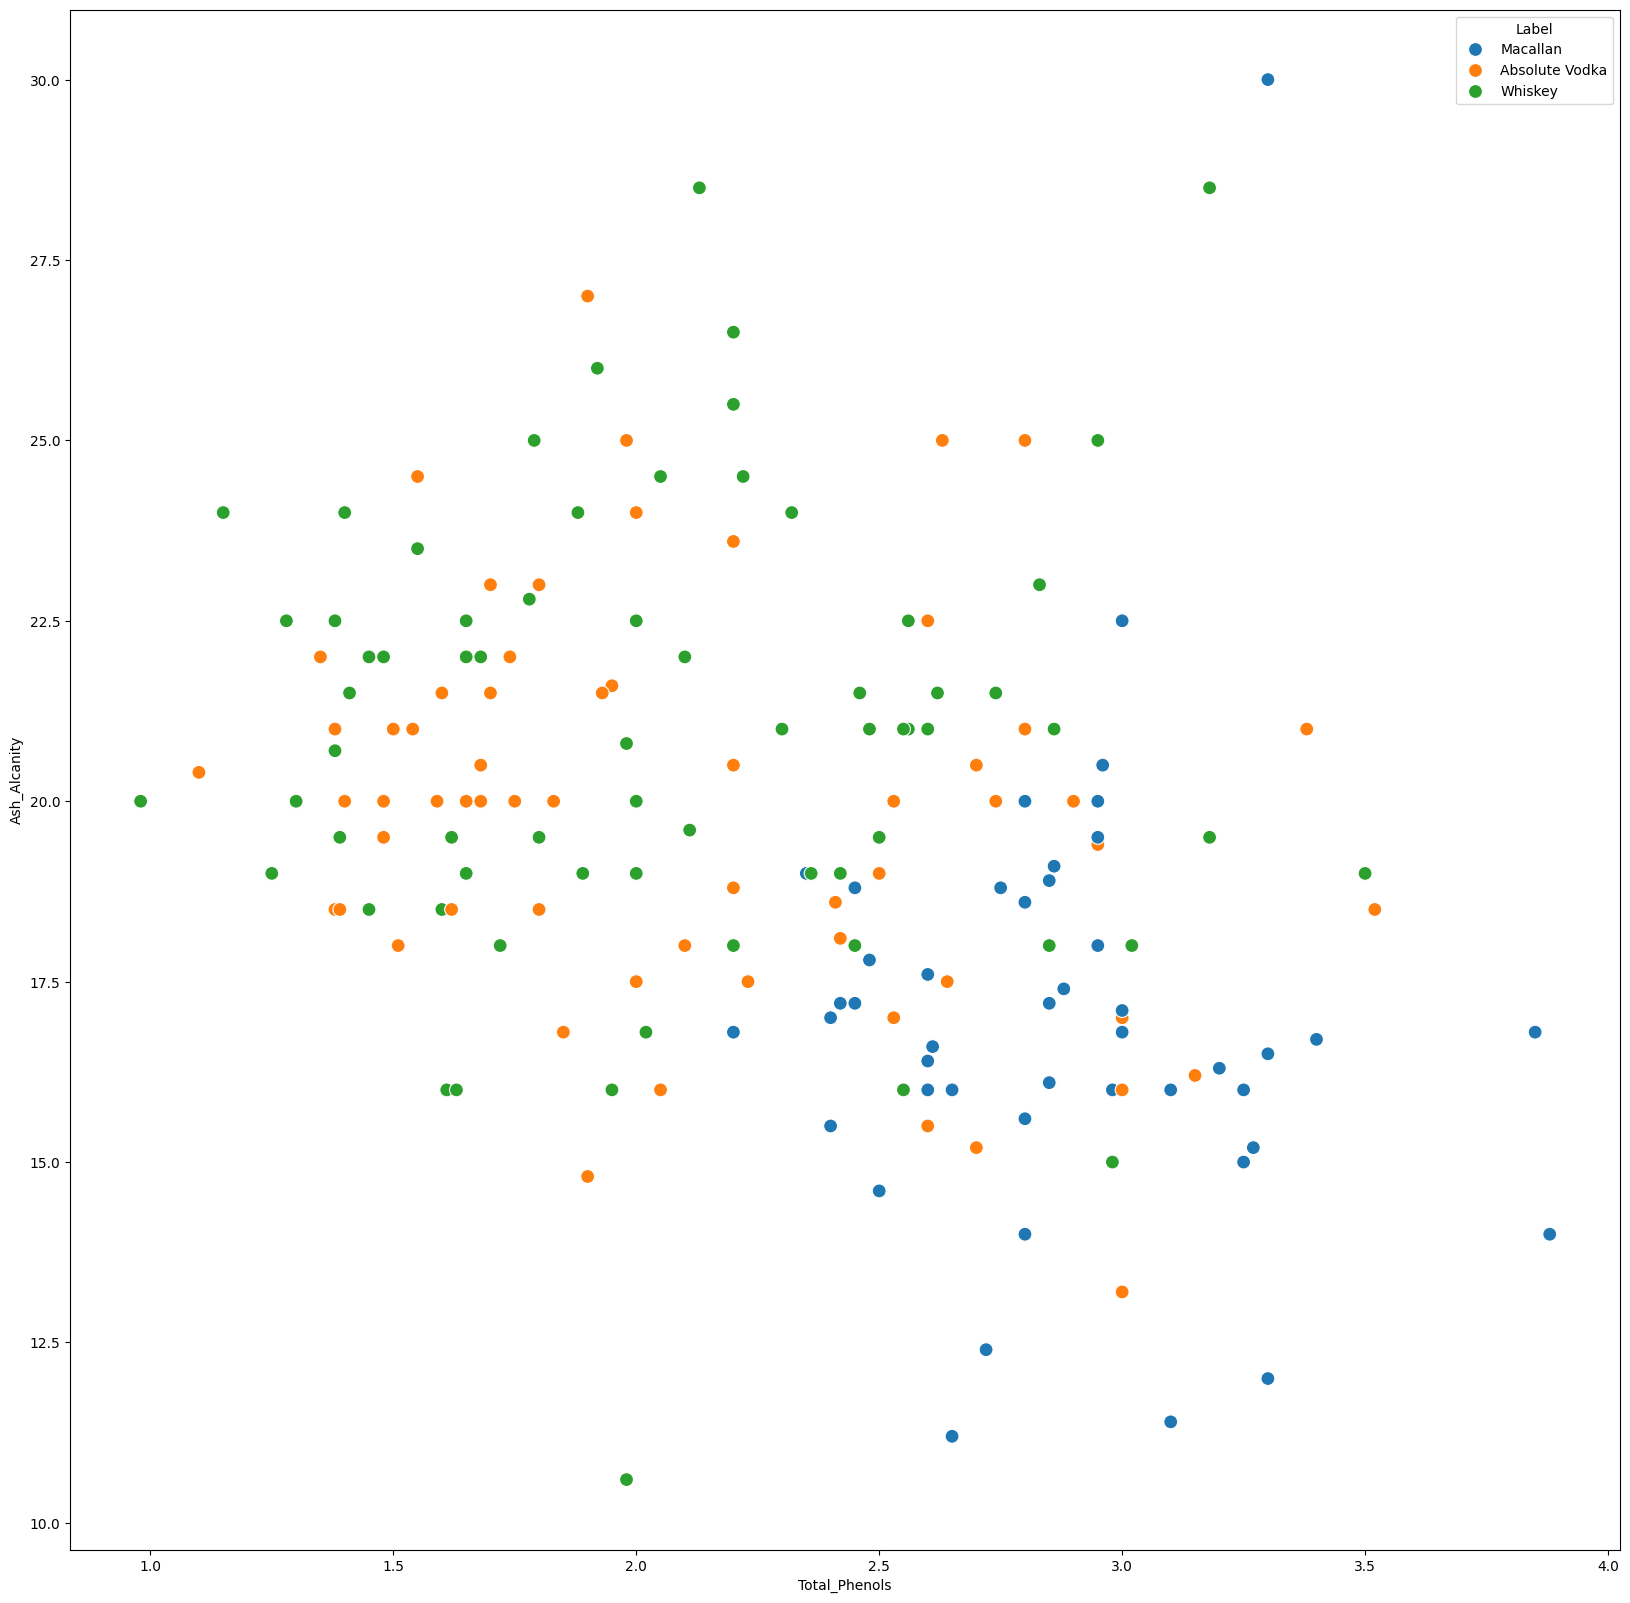

In [31]:
sns.scatterplot(data=df,x='Total_Phenols',y='Ash_Alcanity',hue='Label', s=100)

In [32]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(df)

cluster = kmeans.predict(df)

ValueError: could not convert string to float: 'Macallan'

In [ ]:
# Add cluster labels to dataframe
df['wine-clustering'] = cluster

In [ ]:
# Cluster Profile
cluster_profile = df.groupby('wine-clustering').mean()

display(cluster_profile)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f'
)

plt.title('Cluster Profile Heatmap')
plt.show()

***** REMARK *****

- Khi so sánh centroid giữa các cụm, có thể thấy mỗi cluster mang một đặc trưng hóa học khác nhau, phản ánh các nhóm rượu có profile riêng biệt

- Một số cụm nổi bật ở các biến như **Alcohol, Proline, Flavanoids** hoặc **Color Intensity**, trong khi cụm khác có xu hướng nhẹ và cân bằng hơn

- Từ góc độ business, kết quả này gợi ý rằng doanh nghiệp có thể xem 3 cụm như 3 nhóm sản phẩm tiềm năng với định vị khác nhau. Gợi ý định vị chân dung sản phẩm:
    + Cluster 0 (Premium): Dòng vang cao cấp, đậm đà, độ cồn và chất chống oxy hóa cực cao
    + Cluster 1 (Mass-market): Dòng vang đại chúng nhẹ, thanh mát, nồng độ cồn và khoáng chất thấp
    + Cluster 2 (Niche/Blending): Dòng vang ngách có độ chua gắt và màu thẫm, phù hợp làm cốt rượu phối trộn

# 5. CONCLUSION

Top 5 Insight từ Dữ liệu Rượu vang:

- Sự chênh lệch lớn về thang đo hóa học: Dữ liệu chứa các thuộc tính có thang đo rất khác nhau (Proline lên tới hàng ngàn, trong khi Phenols dưới 1.0). Điều này bắt buộc phải chuẩn hóa dữ liệu (Scaling) để các biến có giá trị lớn không chi phối sai lệch kết quả của thuật toán K-Means

- Tương quan thuận mạnh mẽ giữa các hợp chất Phenol: Heatmap cho thấy Total_Phenols và Flavanoids đi liền với nhau. Sự trùng lặp thông tin này chính là lý do tuyệt vời để chúng ta áp dụng PCA nhằm nén dữ liệu lại cho gọn gàng

- Outliers phản ánh đặc tính thật của dữ liệu: Các giá trị ngoại lệ (outliers) ở Proline hay Alcohol không phải là dữ liệu lỗi, mà nó đại diện cho những chai vang có nồng độ đặc biệt cao (vang xịn/đậm vị). Việc giữ lại chúng là cực kỳ quan trọng để mô hình phân loại đúng

- Xác định 3 phân khúc rượu vang rõ rệt (K=3): Các chỉ số toán học (Elbow, Silhouette) đều chỉ ra K=3 là tối ưu nhất. Khi thử K=4, các dải dữ liệu bị đè lên nhau (over-segmentation), trong khi K=3 chia tách dữ liệu thành 3 khối hoàn hảo trên không gian PCA

- Mỗi cụm mang một đặc trưng hóa học riêng biệt: Cụm 0 là dòng vang cao cấp/đậm đà (Cồn và Proline cao). Cụm 1 là dòng vang đại chúng (Cồn và khoáng chất thấp, dễ uống). Cụm 2 là dòng vang ngách có độ chua gắt (Malic Acid cao) nhưng ít Phenols

# 6. BUSINESS RECOMMENDATIONS

1. Cluster 0 (Dòng Vang Cao Cấp - Premium):

- Chiến lược: Áp dụng định giá hớt váng (Price Skimming) - xây dựng hình ảnh sản phẩm cao cấp, hướng đến khách hàng có thu nhập cao, quà tặng doanh nghiệp và nhà hàng

- Truyền thông: Nhấn mạnh vào cấu trúc rượu đậm đà, quy trình ủ chất lượng cao và đặc biệt làm nổi bật "lợi ích sức khỏe" (do chứa hàm lượng chất chống oxy hóa Phenols/Flavanoids vượt trội)

2. Cluster 1 (Dòng Vang Đại Chúng - Mass Market):

- Chiến lược: Sử dụng chiến lược giá cạnh tranh (Penetration Pricing) để mở rộng thị phần và phủ nhanh nhận diện thương hiệu. Phân phối mạnh qua các kênh siêu thị, cửa hàng tiện lợi

- Truyền thông: Định vị đây là dòng vang dễ uống, nồng độ cồn thấp; phù hợp cho các bữa tiệc nhẹ, dã ngoại hoặc những người mới bắt đầu làm quen với rượu vang

3. Cluster 2 (Dòng Vang Ngách / Phối Trộn - Niche/Blending):

- Chiến lược: Tận dụng đặc tính độ chua cao (Malic Acid cao) để phối trộn (blending) giúp cân bằng hương vị cho các mẻ vang khác trong xưởng nhằm tối ưu chi phí R&D

- Nếu bán lẻ, có thể phát triển phiên bản giới hạn dành cho khách hàng yêu thích hương vị đậm và độ chua đặc trưng

- Truyền thông kết hợp với các gợi ý food pairing như hải sản hoặc các món thịt nhiều mỡ để cân bằng hương vị khi thưởng thức